In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


### Checkig for null values

In [3]:
print(df.shape[0])

df.isna().sum()

5572


v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [4]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis=1, inplace=True)

In [5]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


**Observation** : since Unnamed : 2, Unnamed : 3, and Unnamed : 4 contains hughe number of null values, we removed them.

## Renaming the columns

In [6]:
df.rename(columns={'v1':'TARGET', 'v2':'INPUT'}, inplace=True)

In [7]:
df.head()

,TARGET,INPUT
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Using LabelEncoder() on TARGET

In [8]:
le = LabelEncoder()

df['TARGET'] = le.fit_transform(df['TARGET'])
print("0 corresponds to:", le.classes_[0])
print("1 corresponds to:", le.classes_[1])
df.head()

0 corresponds to: ham
1 corresponds to: spam


,TARGET,INPUT
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Checking for duplicates

In [9]:
print(df.duplicated().sum())

403


In [10]:
df.drop_duplicates(keep='first')

,TARGET,INPUT
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


### EDA

First we need to check what percentage of datas are spam and not spams

In [11]:
print(df['TARGET'].value_counts())

total_0 = df[df['TARGET'] == 0].shape[0]
total_1 = df[df['TARGET'] == 1].shape[0]

total = total_0 + total_1

percentage_0 = (total_0/total) * 100
percentage_1 = (total_1/total) * 100


print(f"\nPERCENTAGE OF 0 : {np.round(percentage_0, 2)} %")
print(f"PERCENTAGE OF 1 : {np.round(percentage_1, 2)} %")

TARGET
0    4825
1     747
Name: count, dtype: int64

PERCENTAGE OF 0 : 86.59 %
PERCENTAGE OF 1 : 13.41 %


Making a pie chart to do the same

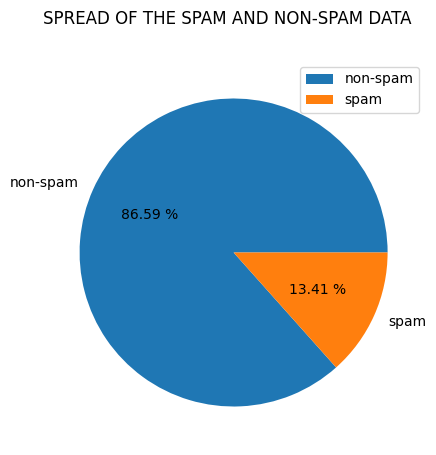

In [12]:
plt.figure(figsize=(5,5))
plt.pie(df['TARGET'].value_counts(), labels=['non-spam', 'spam'], autopct="%0.2f %%")
plt.suptitle('SPREAD OF THE SPAM AND NON-SPAM DATA')
plt.legend()
plt.show()

**Observation** : As we can see from the above data, that we have a case of **imbalanced dataset**, as we have 86% of non-spam data and only 13 % of spam data.

##### **Since we have only one input feature, hence to move forward with the data, we need to make 3 new features.**

Features required :
- NO_OF_CHARS : shows total numbers of characters in the sentence
- NO_OF_WORDS : shows total number of words in the sentence
- NO_OF_SENTNS : shows total number of sentences

In [13]:
import nltk
# from nltk.corpus import stopwords

nltk.download('punkt_tab')          # an important step during spam SMS detection
nltk.download('stopwords')          # used for the stopwords

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\biswa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\biswa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

If you are using `nltk` to split text into individual words or sentences (which is generally called tokenization, a very common step in Email Spam Detection), `nltk` requires a specific set of rules to know how to split the English language correctly. That rule set is called `punkt`.

Even though you `pip installed nltk`, it doesn't download all of its datasets by default because they are very large. You build it by hand.

In [14]:
# storing the characters
df['NO_OF_CHARS'] = df['INPUT'].apply(len)

# storing the words
df['NO_OF_WORDS'] = df['INPUT'].apply(lambda x : len(nltk.word_tokenize(x)))

# storing the sentences
df['NO_OF_SENTNS'] = df['INPUT'].apply(lambda x : len(nltk.sent_tokenize(x)))

df.head()

,TARGET,INPUT,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


### Doing Stemming
- Stemming
- Lower casing the texts
- Dropping the symbols
- Dropping the stopwords

In [15]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
st = PorterStemmer()

stop_words = stopwords.words('english')

# making a function to do the stemming
def transform(text):
    text = text.lower()
    text = nltk.word_tokenize(text)        # it will drop all the symbols used in the text, and will only keep the word 

    # removing the symbols and stopwords
    temp = []
    for i in text:
        if i.isalnum() and i not in stop_words:
            temp.append(i)

    text = temp[:]
    temp.clear()

    # doing stemming
    temp = []
    for i in text:
        temp.append(st.stem(i))

    return " ".join(temp)

In [16]:
print(transform('did you like the presentation i sent you last monday ???'))
print(transform("would you like to mine for new bitcoins"))

like present sent last monday
would like mine new bitcoin


In [17]:
df['TRANSFORMED_WORDS'] = df['INPUT'].apply(transform)
df.head()

,TARGET,INPUT,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS,TRANSFORMED_WORDS
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


**Observation** : As it important to have ALL_WORDS so that the ML model can detect which words affect the model most for making it a spam or non-spam. And afterwards we will be dropping INPUT feature.

It is not strictly required for the final algorithm (because machine learning tools like `sklearn`'s `CountVectorizer` or `TfidfVectorizer` can take a full sentence and split it into words automatically behind the scenes).

However, it is HIGHLY **RECOMMENDED** to do it exactly the way we have done here.

In [18]:
df[['NO_OF_CHARS','NO_OF_WORDS','NO_OF_SENTNS']].describe()

,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS
count,5572.000000,5572.000000,5572.000000
mean,80.118808,18.699390,1.996411
std,59.690841,13.741932,1.520159
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.500000
75%,121.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [19]:
df[df['TARGET'] == 0][['NO_OF_CHARS','NO_OF_WORDS','NO_OF_SENTNS']].describe()

,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS
count,4825.000000,4825.000000,4825.000000
mean,71.023627,17.276269,1.837720
std,58.016023,13.988585,1.454388
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,92.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [20]:
df[df['TARGET'] == 1][['NO_OF_CHARS','NO_OF_WORDS','NO_OF_SENTNS']].describe()

,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS
count,747.000000,747.000000,747.000000
mean,138.866131,27.891566,3.021419
std,29.183082,6.867007,1.537580
min,13.000000,2.000000,1.000000
25%,132.500000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000



**Observation** : Here we can make an observation that mean for spam SMS are quite higher compared to non-spam SMS, this is bcoz usually spam messages are quite lengthier in context. But it can also be contradicted by saying that if someone is writing a personal birthday SMS or some farewell SMS etc. the said SMS can also be lengthier. Which is proven from the `max` is quite higher in non-spam compared to spam.

### Plotting Histograms for better EDA

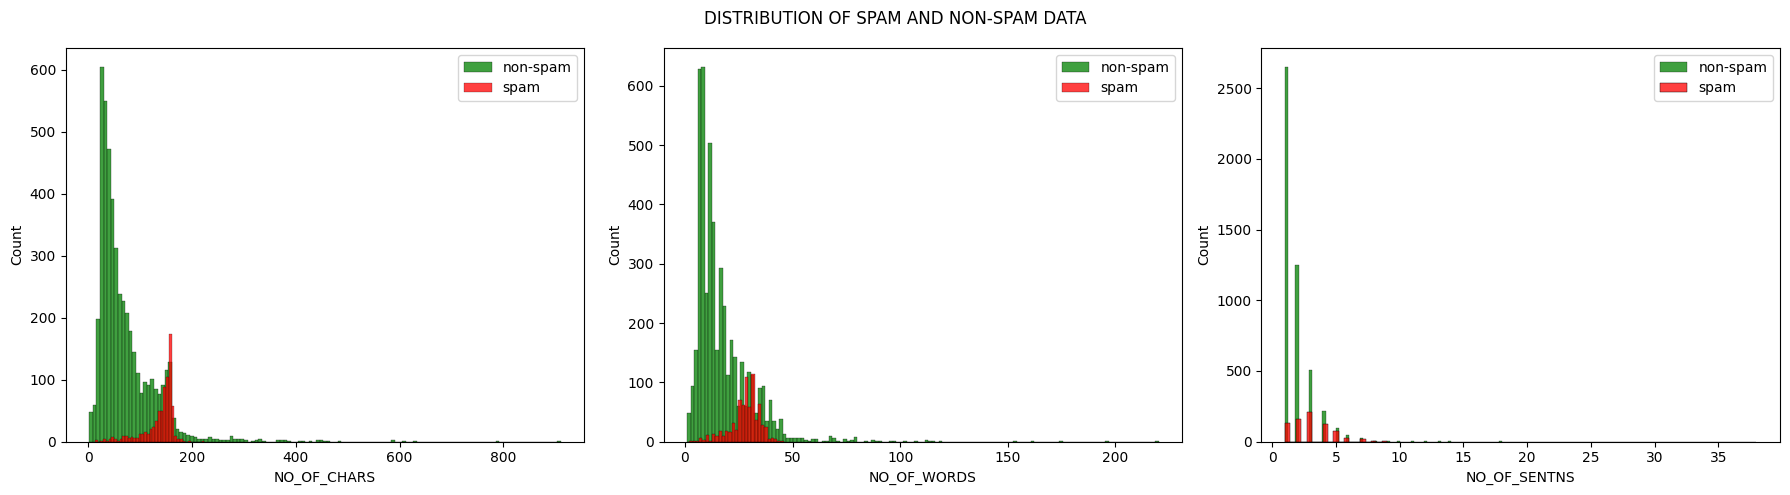

In [21]:
plt.figure(figsize=(18,5))
plt.subplot(131)
sns.histplot(df[df['TARGET'] == 0]['NO_OF_CHARS'], color='g', label='non-spam')
sns.histplot(df[df['TARGET'] == 1]['NO_OF_CHARS'], color='r', label='spam')
plt.legend()

plt.subplot(132)
sns.histplot(df[df['TARGET'] == 0]['NO_OF_WORDS'], color='g', label='non-spam')
sns.histplot(df[df['TARGET'] == 1]['NO_OF_WORDS'], color='r', label='spam')
plt.legend()

plt.subplot(133)
sns.histplot(df[df['TARGET'] == 0]['NO_OF_SENTNS'], color='g', label='non-spam')
sns.histplot(df[df['TARGET'] == 1]['NO_OF_SENTNS'], color='r', label='spam')

plt.legend()
plt.suptitle('DISTRIBUTION OF SPAM AND NON-SPAM DATA')
plt.tight_layout()
plt.show()

<Figure size 2000x1000 with 0 Axes>

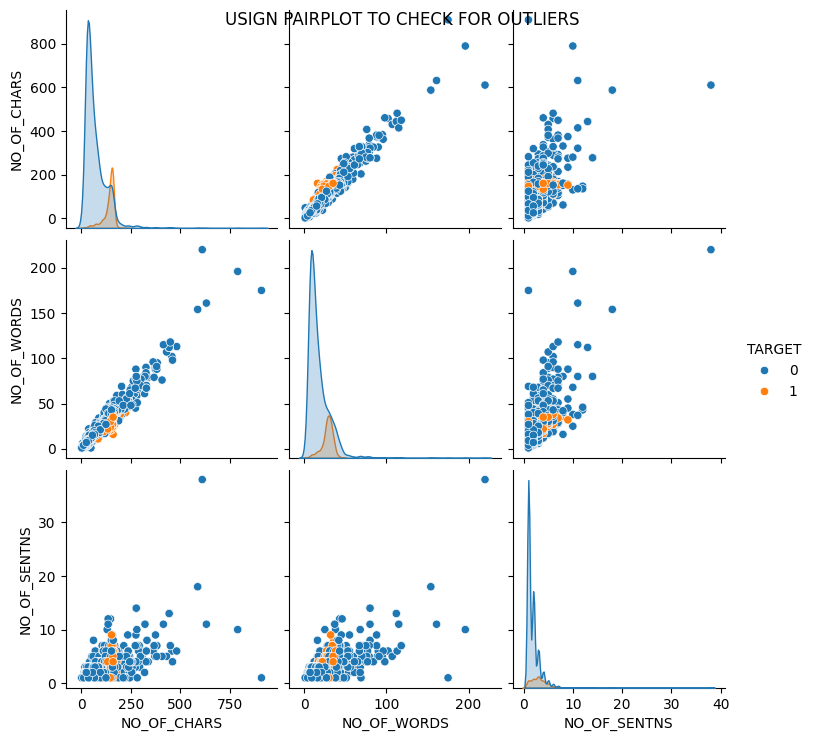

In [22]:
plt.figure(figsize=(20,10))
sns.pairplot(df, hue='TARGET')
plt.suptitle('USIGN PAIRPLOT TO CHECK FOR OUTLIERS')
plt.show()

### Using `WordCloud`

`WordCloud` is used to detect the words which are being repeated multiple times for the spam SMS. (for eg. words like FREE, link, click, crypto, etc)

In [23]:
from wordcloud import WordCloud
wc = WordCloud(
    width=500,
    height=500,
    min_font_size=5,
    background_color='black'
)

Text(0.5, 0.98, 'WORDS THAT MARKS AN SMS AS SPAM')

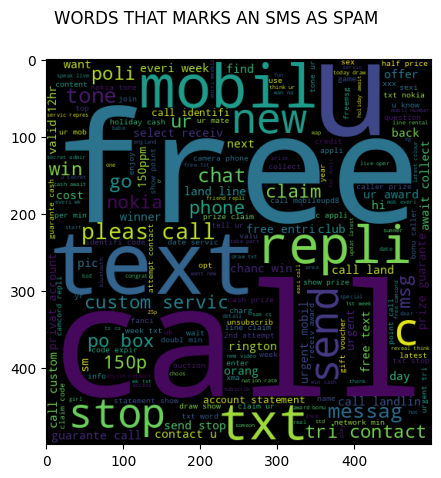

In [24]:
spams = wc.generate(df[df['TARGET'] == 1]['TRANSFORMED_WORDS'].str.cat(sep=" "))

plt.figure(figsize=(18,5))
plt.imshow(spams)
plt.suptitle("WORDS THAT MARKS AN SMS AS SPAM")

**Observation** : As we can see form above image, that words like call, free, text, txt, stop, send etc are the words which marks ans sms as spam.

Text(0.5, 0.98, 'WORDS THAT MARKS AN SMS AS NON-SPAM')

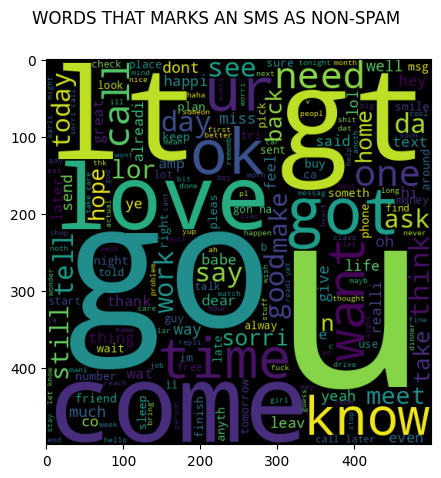

In [25]:
non_spam = wc.generate(df[df['TARGET'] == 0]['TRANSFORMED_WORDS'].str.cat(sep=" "))

plt.figure(figsize=(18,5))
plt.imshow(non_spam)
plt.suptitle("WORDS THAT MARKS AN SMS AS NON-SPAM")

### Printing the details of how many times the spam words are being repeated

In [26]:
spam_words = []

for msg in df[df['TARGET'] == 1]['TRANSFORMED_WORDS']:
    for words in msg.split():
        spam_words.append(words)

print(len(spam_words))
print(spam_words)

11490
['free', 'entri', '2', 'wkli', 'comp', 'win', 'fa', 'cup', 'final', 'tkt', '21st', 'may', 'text', 'fa', '87121', 'receiv', 'entri', 'question', 'std', 'txt', 'rate', 'c', 'appli', '08452810075over18', 'freemsg', 'hey', 'darl', '3', 'week', 'word', 'back', 'like', 'fun', 'still', 'tb', 'ok', 'xxx', 'std', 'chg', 'send', 'rcv', 'winner', 'valu', 'network', 'custom', 'select', 'receivea', 'prize', 'reward', 'claim', 'call', 'claim', 'code', 'kl341', 'valid', '12', 'hour', 'mobil', '11', 'month', 'u', 'r', 'entitl', 'updat', 'latest', 'colour', 'mobil', 'camera', 'free', 'call', 'mobil', 'updat', 'co', 'free', '08002986030', 'six', 'chanc', 'win', 'cash', '100', 'pound', 'txt', 'csh11', 'send', 'cost', '6day', 'tsandc', 'appli', 'repli', 'hl', '4', 'info', 'urgent', '1', 'week', 'free', 'membership', 'prize', 'jackpot', 'txt', 'word', 'claim', '81010', 'c', 'lccltd', 'pobox', '4403ldnw1a7rw18', 'xxxmobilemovieclub', 'use', 'credit', 'click', 'wap', 'link', 'next', 'txt', 'messag', 'c

In [27]:
from collections import Counter
# a = Counter(spam_words).most_common(50)

Counter(spam_words).most_common(50)         #  will print top 50 common words, if you remove "most_common" it will print for all the words and how many times they are being repeated

[('call', 365),
 ('free', 219),
 ('2', 174),
 ('txt', 169),
 ('ur', 144),
 ('u', 141),
 ('text', 139),
 ('mobil', 135),
 ('4', 120),
 ('claim', 115),
 ('stop', 114),
 ('repli', 112),
 ('prize', 94),
 ('get', 88),
 ('tone', 74),
 ('servic', 72),
 ('send', 70),
 ('new', 69),
 ('nokia', 68),
 ('award', 66),
 ('week', 62),
 ('cash', 62),
 ('urgent', 62),
 ('win', 61),
 ('contact', 61),
 ('pleas', 57),
 ('phone', 57),
 ('c', 51),
 ('custom', 51),
 ('collect', 51),
 ('min', 51),
 ('guarante', 50),
 ('per', 46),
 ('messag', 45),
 ('chat', 45),
 ('cs', 41),
 ('draw', 40),
 ('offer', 40),
 ('tri', 39),
 ('number', 39),
 ('today', 38),
 ('receiv', 37),
 ('latest', 37),
 ('line', 37),
 ('msg', 36),
 ('voucher', 36),
 ('show', 35),
 ('1', 34),
 ('rington', 34),
 ('150ppm', 34)]

Checking for the words which are being repeted for more than 50 times, as they are most likely to be spam.

**IMPORTANT** : Keep in mind, setting the minmum quota is very imp, if you set the quota too low, it will start picking the random noise, but if you set it very high it will start ignoring the words, might even miss the words which are found in spam SMS. Hence to proceed with the quota academic knowledge and consultation is adviced.

It is always advised that rather than using any number as quota we should always use percentage as a quota.

In [28]:
a = [(word, count) for word, count in Counter(spam_words).items() if count > 30]
a.sort(key=lambda x : x[1] ,reverse=True)       # lambda function is doing the sorting based the number, you remove the lambda function it will do the sorting based on the words

print(len(a))
a

58


[('call', 365),
 ('free', 219),
 ('2', 174),
 ('txt', 169),
 ('ur', 144),
 ('u', 141),
 ('text', 139),
 ('mobil', 135),
 ('4', 120),
 ('claim', 115),
 ('stop', 114),
 ('repli', 112),
 ('prize', 94),
 ('get', 88),
 ('tone', 74),
 ('servic', 72),
 ('send', 70),
 ('new', 69),
 ('nokia', 68),
 ('award', 66),
 ('week', 62),
 ('cash', 62),
 ('urgent', 62),
 ('win', 61),
 ('contact', 61),
 ('pleas', 57),
 ('phone', 57),
 ('c', 51),
 ('custom', 51),
 ('collect', 51),
 ('min', 51),
 ('guarante', 50),
 ('per', 46),
 ('messag', 45),
 ('chat', 45),
 ('cs', 41),
 ('draw', 40),
 ('offer', 40),
 ('tri', 39),
 ('number', 39),
 ('today', 38),
 ('receiv', 37),
 ('latest', 37),
 ('line', 37),
 ('msg', 36),
 ('voucher', 36),
 ('show', 35),
 ('1', 34),
 ('rington', 34),
 ('150ppm', 34),
 ('landlin', 34),
 ('go', 34),
 ('camera', 33),
 ('everi', 33),
 ('holiday', 32),
 ('want', 32),
 ('rate', 31),
 ('select', 31)]

### Setting the quota for 5%

In [29]:
# quota = len(spam_words) * 0.05                
quota = len(df[df['TARGET'] == 1]) * 0.05   # rather than taking 5 % of the whole dataset we took 5 % of the spam dataset

spam = [(word, count) for word, count in Counter(spam_words).items() if count > quota]

spam.sort(key=lambda x : x[1], reverse=True)       

print(len(spam))
spam

41


[('call', 365),
 ('free', 219),
 ('2', 174),
 ('txt', 169),
 ('ur', 144),
 ('u', 141),
 ('text', 139),
 ('mobil', 135),
 ('4', 120),
 ('claim', 115),
 ('stop', 114),
 ('repli', 112),
 ('prize', 94),
 ('get', 88),
 ('tone', 74),
 ('servic', 72),
 ('send', 70),
 ('new', 69),
 ('nokia', 68),
 ('award', 66),
 ('week', 62),
 ('cash', 62),
 ('urgent', 62),
 ('win', 61),
 ('contact', 61),
 ('pleas', 57),
 ('phone', 57),
 ('c', 51),
 ('custom', 51),
 ('collect', 51),
 ('min', 51),
 ('guarante', 50),
 ('per', 46),
 ('messag', 45),
 ('chat', 45),
 ('cs', 41),
 ('draw', 40),
 ('offer', 40),
 ('tri', 39),
 ('number', 39),
 ('today', 38)]

**Observation** : Here rather than taking 5% of the whole dataset we took 5% of the spam dataset bcoz, he math behind the 5% threshold is much larger than we think.
- We have 747 Spam messages.
- The average spam message has about 27 words.
- So, len(spam_words) (the total number of words) is roughly 20,000.
- 5% of 20,000 is 1,000.


For a massive 5% chunk of every single word written. Even the most common words probably only appear a few hundred times total.


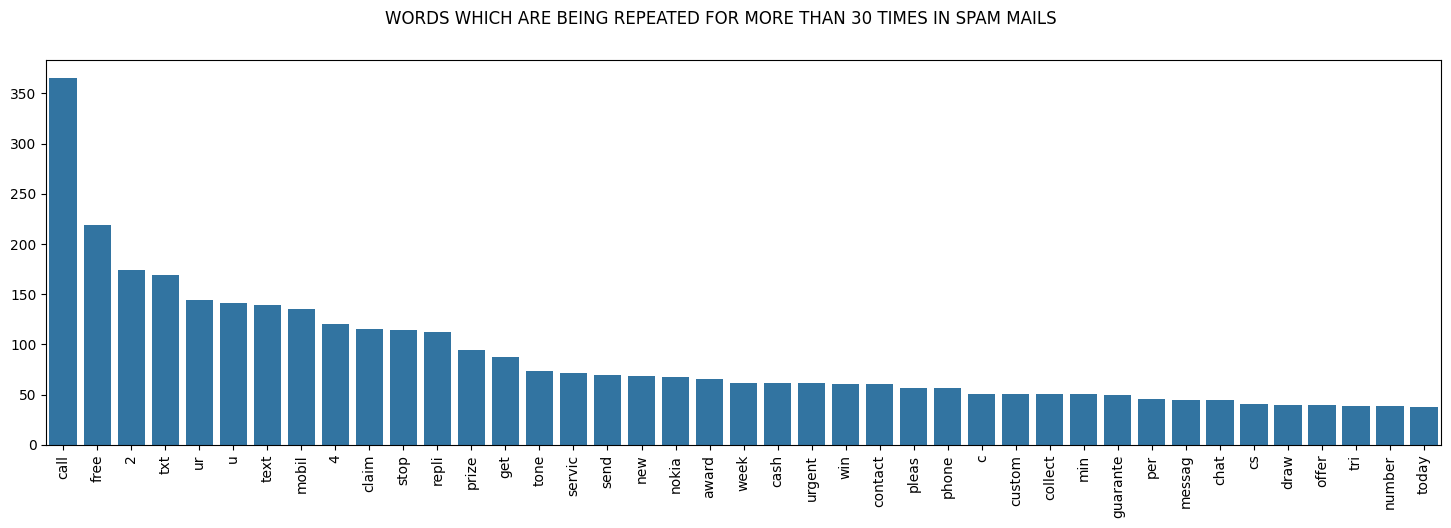

In [30]:
words = [i[0] for i in spam]
repetations = [i[1] for i in spam]


plt.figure(figsize=(18,5))
sns.barplot(x=words, y=repetations)
plt.suptitle('WORDS WHICH ARE BEING REPEATED FOR MORE THAN 30 TIMES IN SPAM MAILS')
plt.xticks(rotation='vertical')
plt.show()

In [31]:
df.head(10)

,TARGET,INPUT,NO_OF_CHARS,NO_OF_WORDS,NO_OF_SENTNS,TRANSFORMED_WORDS
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
5,1,FreeMsg Hey there darling it's been 3 week's n...,148,39,4,freemsg hey darl 3 week word back like fun sti...
6,0,Even my brother is not like to speak with me. ...,77,18,2,even brother like speak treat like aid patent
7,0,As per your request 'Melle Melle (Oru Minnamin...,160,31,2,per request mell oru minnaminungint nurungu ve...
8,1,WINNER!! As a valued network customer you have...,158,32,5,winner valu network custom select receivea pri...
9,1,Had your mobile 11 months or more? U R entitle...,154,31,3,mobil 11 month u r entitl updat latest colour ...


In [32]:
import pickle
pickle.dump(df, open('df.pkl','wb'))
pickle.dump(spam, open('spam.pkl','wb'))